## Problem Statement

Diabetes is one of the most prevalent chronic diseases among U.S. adults, driving significant long-term health and economic costs nationwide. To mitigate this problem:

Analyze national diabetes prevalence trends from 2011–2021.

Examine changes in diabetes-related mortality from 2010–2020.

Compare diabetes prevalence across U.S. states.

Identify demographic groups with the highest prevalence.

Finally, use data-driven patterns to support targeted public health decision-making


## Objectives

1. How has national diabetes prevalence and mortality changed from 2010-2021, and is the rate of increase accelerating?

2. Which U.S. states carried the highest and lowest 2021 prevalence, and how far do they deviate from the national average?

3. How does prevalence differ by gender and race/ethnicity, and has that gap widened or narrowed over the decade?

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

PRIMARY ="steelblue"
HIGH ="firebrick"
LOW ="forestgreen"
NEUTRAL ="darkgray"
PALETTE_GENDER ={"Male": "steelblue","Female": "goldenrod"}

In [44]:
df=pd.read_csv("U.S._Chronic_Disease.csv", low_memory=False)
df.shape

(1185676, 34)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185676 entries, 0 to 1185675
Data columns (total 34 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   YearStart                  1185676 non-null  int64  
 1   YearEnd                    1185676 non-null  int64  
 2   LocationAbbr               1185676 non-null  object 
 3   LocationDesc               1185676 non-null  object 
 4   DataSource                 1185676 non-null  object 
 5   Topic                      1185676 non-null  object 
 6   Question                   1185676 non-null  object 
 7   Response                   0 non-null        float64
 8   DataValueUnit              1033553 non-null  object 
 9   DataValueType              1185676 non-null  object 
 10  DataValue                  806942 non-null   object 
 11  DataValueAlt               804578 non-null   float64
 12  DataValueFootnoteSymbol    393710 non-null   object 
 13  DatavalueFoo

In [7]:
df["DataValue"].isnull().sum()

np.int64(378734)

In [8]:
df.duplicated().sum()

np.int64(0)

## DATA HANDLING

In [45]:
Q_PREV="Prevalence of diagnosed diabetes among adults aged >= 18 years"
Q_MORT="Mortality due to diabetes reported as any listed cause of death"

df["DataValue"]=pd.to_numeric(df["DataValue"], errors="coerce")
df =df[(df["Topic"] == "Diabetes")&((df["Question"] == Q_PREV)|(df["Question"] == Q_MORT))]
df.shape

(23067, 34)

In [68]:
df =df[["YearStart", "LocationAbbr", "LocationDesc", "Question", "DataValueUnit","DataValueType", "DataValue", "LowConfidenceLimit", "HighConfidenceLimit","StratificationCategory1", "Stratification1"]]
df.columns

Index(['YearStart', 'LocationAbbr', 'LocationDesc', 'Question',
       'DataValueUnit', 'DataValueType', 'DataValue', 'LowConfidenceLimit',
       'HighConfidenceLimit', 'StratificationCategory1', 'Stratification1'],
      dtype='object')

In [69]:
df_clean= df[((df["Question"] == Q_PREV) & (df["DataValueType"] == "Age-adjusted Prevalence")) |((df["Question"] == Q_MORT) & (df["DataValueType"] == "Number"))]
df_clean= df_clean.copy()

df_clean["DataValueUnit"] =df_clean["DataValueUnit"].fillna("Number")
df_clean =df_clean.drop_duplicates()
df_clean =df_clean.dropna(subset=["DataValue"])
df_clean.isnull().sum()

YearStart                     0
LocationAbbr                  0
LocationDesc                  0
Question                      0
DataValueUnit                 0
DataValueType                 0
DataValue                     0
LowConfidenceLimit         3739
HighConfidenceLimit        3739
StratificationCategory1       0
Stratification1               0
dtype: int64

In [70]:
df_prevalence =df_clean[df_clean["Question"] == Q_PREV]
df_mortality =df_clean[df_clean["Question"] == Q_MORT]

df_national =df_prevalence[(df_prevalence["LocationDesc"] == "United States")&(df_prevalence["StratificationCategory1"] == "Overall")]
df_national =df_national.sort_values(by="YearStart")

df_state =df_prevalence[(df_prevalence["LocationDesc"] != "United States")&(df_prevalence["StratificationCategory1"] == "Overall")]

df_gender =df_prevalence[(df_prevalence["LocationDesc"] == "United States")&(df_prevalence["StratificationCategory1"] == "Gender")]
df_gender =df_gender.sort_values(by=["YearStart", "Stratification1"])

df_race =df_prevalence[df_prevalence["StratificationCategory1"] == "Race/Ethnicity"]

df_mortality_national =df_mortality[(df_mortality["LocationDesc"] == "United States")&(df_mortality["StratificationCategory1"] == "Overall")]
df_mortality_national =df_mortality_national.sort_values(by="YearStart")

## Objective 1

In [49]:
df_national["DataValue"].describe()

count    11.000000
mean      9.290909
std       0.287939
min       8.900000
25%       9.050000
50%       9.400000
75%       9.450000
max       9.800000
Name: DataValue, dtype: float64

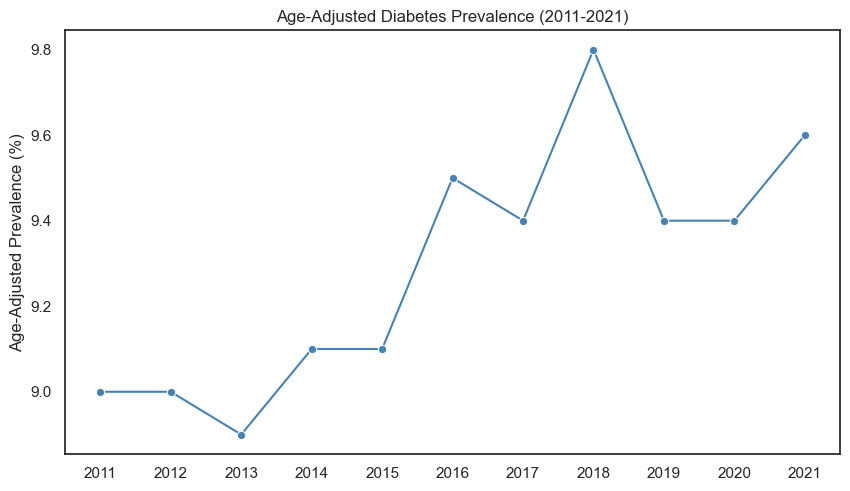

In [95]:
fig, ax = plt.subplots(figsize=(10,5.5))
sns.lineplot(data=df_national, x="YearStart", y="DataValue", marker="o", color=PRIMARY, ax=ax)
ax.set_title("Age-Adjusted Diabetes Prevalence (2011-2021)")
ax.set_xlabel("")
ax.set_ylabel("Age-Adjusted Prevalence (%)")
ax.set_xticks(df_national["YearStart"])
plt.savefig("plot1.png", dpi=200, bbox_inches="tight")


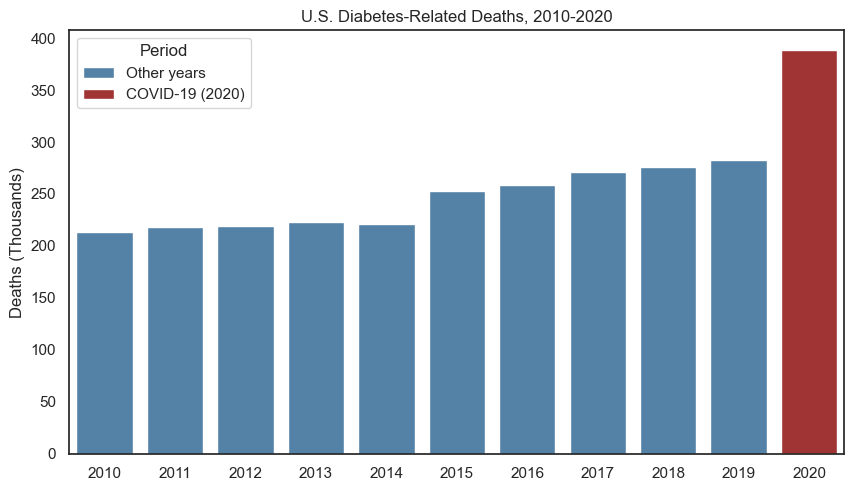

In [93]:
df_mortality_national["DeathsThousands"] =df_mortality_national["DataValue"] / 1000
df_mortality_national["Period"] =["COVID-19 (2020)" if i==2020 else "Other years" for i in df_mortality_national["YearStart"]]

fig, ax = plt.subplots(figsize=(10,5.5))
sns.barplot(data=df_mortality_national, x="YearStart", y="DeathsThousands", hue="Period",palette={"COVID-19 (2020)": HIGH, "Other years": PRIMARY}, dodge=False, ax=ax)
ax.set_title("U.S. Diabetes-Related Deaths, 2010-2020")
ax.set_xlabel("")
ax.set_ylabel("Deaths (Thousands)")
plt.savefig("plot2.png", dpi=200, bbox_inches="tight")

## Objective 2

In [52]:
state_2021=df_state[df_state["YearStart"]==2021]
state_2021=state_2021.sort_values(by="DataValue",ascending=False)
state_2021 = state_2021.copy()
state_2021["Type"]=["Unincorporated Territories" if i in ("Puerto Rico", "Guam", "Virgin Islands") else "State" for i in state_2021["LocationDesc"]]
state_2021["LocationDesc"].nunique()

53

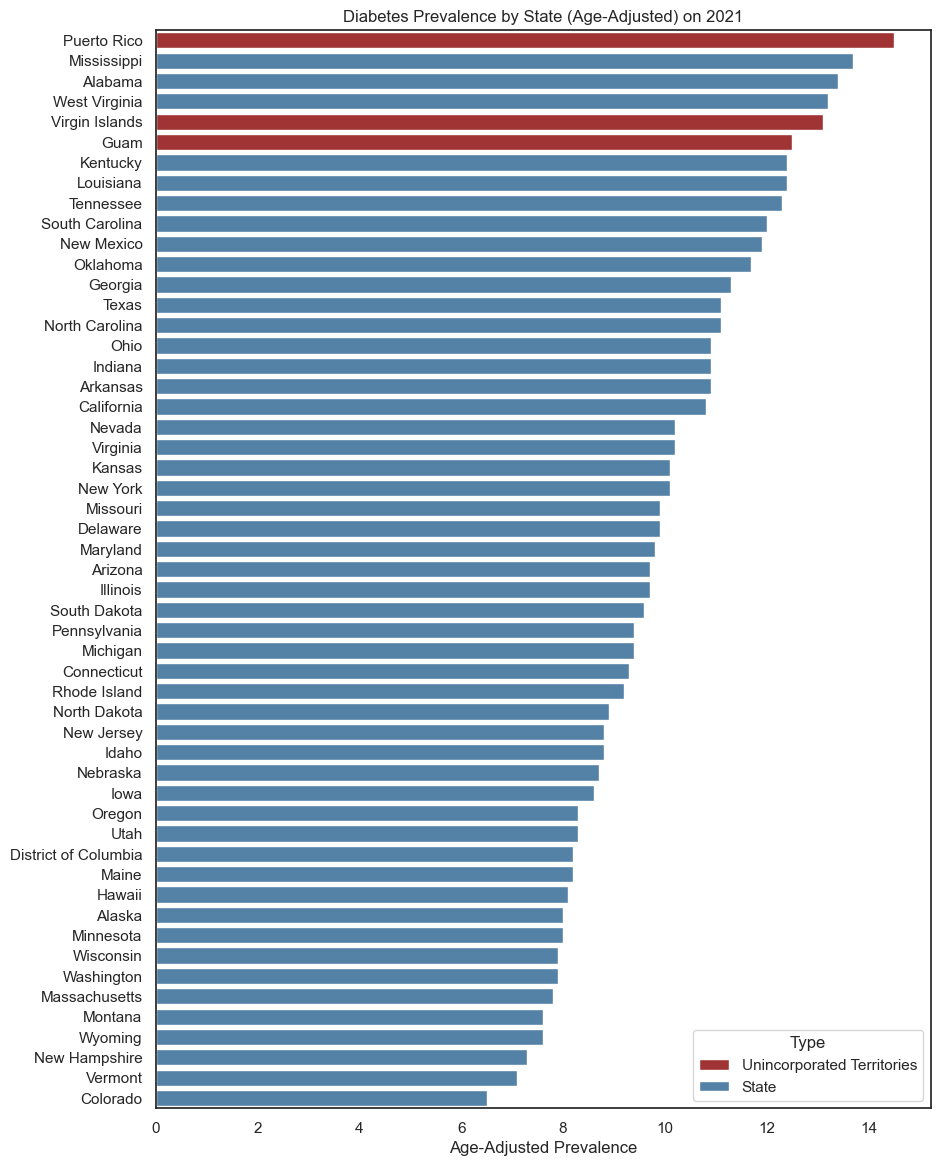

In [98]:
fig, ax = plt.subplots(figsize=(10,14))
sns.barplot(data=state_2021,x="DataValue",y="LocationDesc",hue="Type",palette={"State":PRIMARY ,"Unincorporated Territories":HIGH},dodge=False, ax=ax)
ax.set_title("Diabetes Prevalence by State (Age-Adjusted) on 2021")
ax.set_xlabel("Age-Adjusted Prevalence")
ax.set_ylabel("")
plt.savefig("plot3.png", dpi=200, bbox_inches="tight")

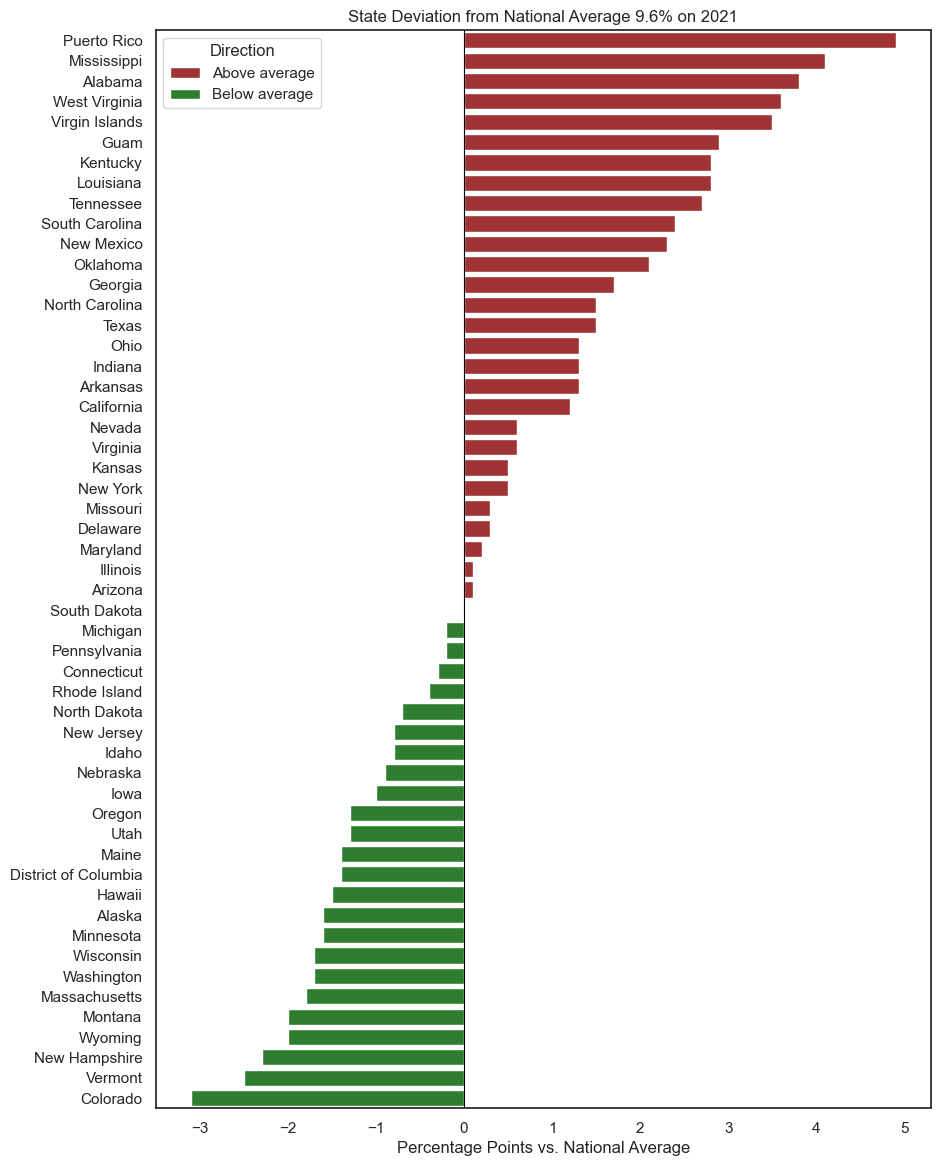

In [89]:
national_avg_2021 =df_national.loc[df_national["YearStart"]==2021,"DataValue"].mean()
dev =state_2021.copy()
dev["Deviation"] =dev["DataValue"]-national_avg_2021
dev["Direction"] =["Above average" if d > 0 else "Below average" for d in dev["Deviation"]]
dev = dev.sort_values("Deviation",ascending=False)
fig, ax =plt.subplots(figsize=(10, 14))
sns.barplot(data=dev, y="LocationDesc", x="Deviation", hue="Direction", palette={"Above average": HIGH,"Below average": LOW}, dodge=False, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"State Deviation from National Average {national_avg_2021}% on 2021")
ax.set_xlabel("Percentage Points vs. National Average")
ax.set_ylabel("")
plt.savefig("plot4.png", dpi=200, bbox_inches="tight")

## Objective 3

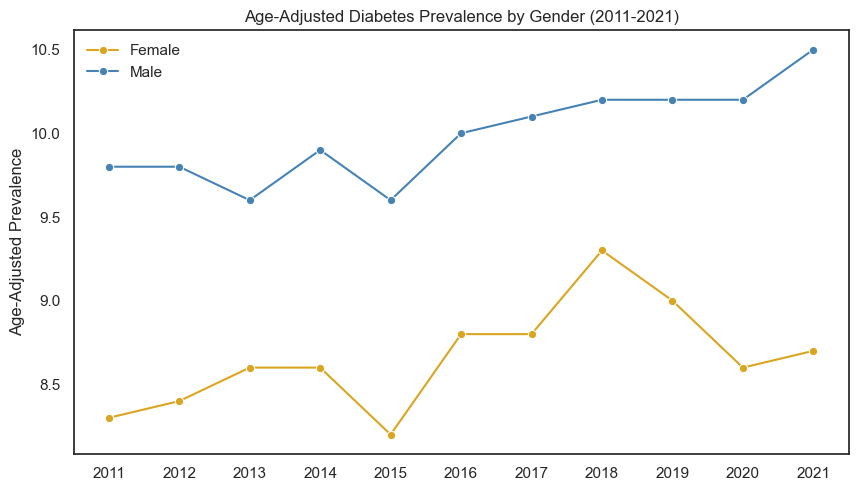

In [97]:
fig, ax =plt.subplots(figsize=(10, 5.5))
sns.lineplot(data=df_gender, x="YearStart", y="DataValue", hue="Stratification1", palette=PALETTE_GENDER, marker="o", ax=ax)
ax.set_title("Age-Adjusted Diabetes Prevalence by Gender (2011-2021)")
ax.set_ylabel("Age-Adjusted Prevalence")
ax.set_xlabel("")
ax.set_xticks(df_gender["YearStart"].unique())
ax.legend(title="", loc="upper left", frameon=False)
plt.savefig("plot5.png", dpi=200, bbox_inches="tight")

In [56]:
race_2021 =df_race[df_race["YearStart"]==2021]
race_avg =race_2021.groupby("Stratification1")["DataValue"].mean()
race_avg =race_avg.sort_values(ascending=False)
race_avg

Stratification1
Black, non-Hispanic          14.548718
Hispanic                     14.293478
Multiracial, non-Hispanic    13.332258
Other, non-Hispanic          12.393878
White, non-Hispanic           8.274510
Name: DataValue, dtype: float64

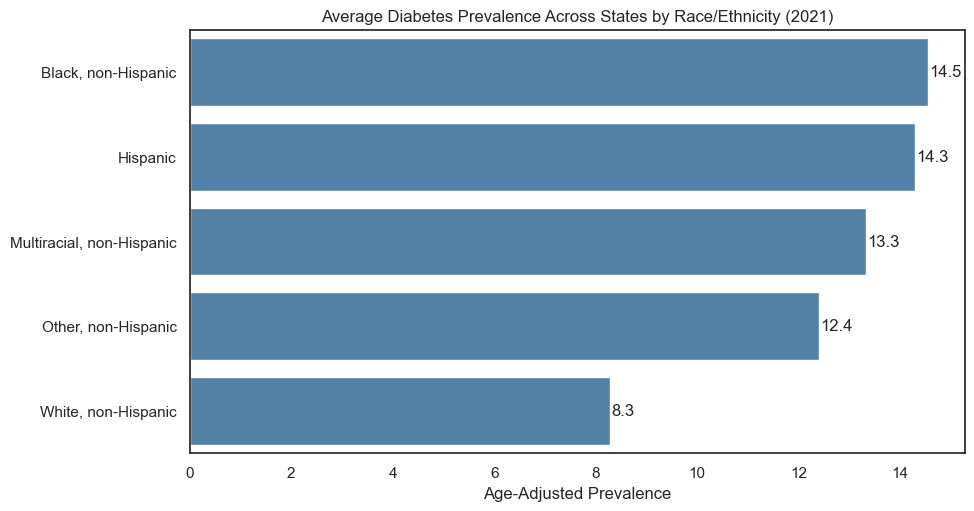

In [85]:
fig, ax=plt.subplots(figsize=(10,5.5))
sns.barplot(x=race_avg.values, y=race_avg.index, color=PRIMARY, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=1)
ax.set_title("Average Diabetes Prevalence Across States by Race/Ethnicity (2021)")
ax.set_xlabel("Age-Adjusted Prevalence")
ax.set_ylabel("")
plt.savefig("plot6.png", dpi=200, bbox_inches="tight",transparent=True)

## 7. Conclusion

National age-adjusted diabetes prevalence has stayed close to flat (9.0% to 9.6%, 2011-2021), while diabetes-related deaths rose sharply (~213K to ~388K, 2010-2020)

Burden is geographically concentrated: Southern states and Puerto Rico carry the highest prevalence; Colorado and the Northeast carry the lowest

Men show consistently higher prevalence than women across the full decade

Black, non-Hispanic, and Hispanic adults face roughly 1.7x the prevalence of White, non-Hispanic adults

The findings demonstrate that diabetes remains a significant public health challenge despite relatively small changes in national prevalence.


## 8. Recommendations

Prioritize diabetes prevention and screening programs in high-prevalence regions, particularly Mississippi, Alabama, Louisiana, and Puerto Rico.

Expand culturally appropriate education, screening, and healthcare access for Black, non-Hispanic and Hispanic communities to help reduce demographic disparities.

Promote healthier lifestyles through community initiatives that encourage balanced nutrition, regular physical activity, and early diabetes screening.

Improve data collection and reporting consistency, particularly by addressing missing data such as Florida's 2021 prevalence records.

Continue monitoring national and state-level diabetes trends to evaluate the effectiveness of public health interventions over time.